# Phase 3: Recommendation System

In this notebook, you will:
1. Build a content-based filtering system using property features
2. Implement collaborative filtering (user-based and item-based)
3. Create a hybrid recommendation system
4. Evaluate recommendation quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.recommendation import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Properties: {X_scaled.shape[0]}, Features: {X_scaled.shape[1]}")

Properties: 20640, Features: 8


## 2. Content-Based Filtering

Similarity matrix shape: (500, 500)
Value range: [-0.4519, 1.0000]

Top-5 content-based recommendations for property #42:
  Property   81  —  similarity: 0.9938
  Property   71  —  similarity: 0.9933
  Property   35  —  similarity: 0.9915
  Property   55  —  similarity: 0.9910
  Property   66  —  similarity: 0.9910


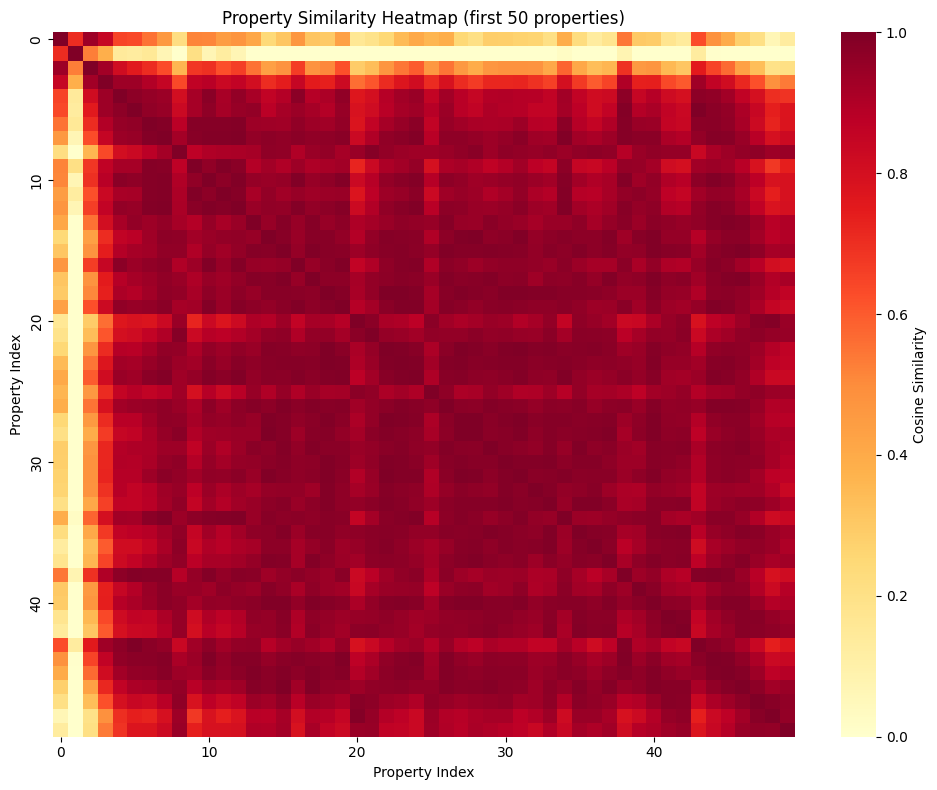

In [3]:

# Compute similarity matrix on a manageable subset
SUBSET_SIZE = 500
SAMPLE_PROPERTY = 42

X_subset = X_scaled[:SUBSET_SIZE]
similarity_matrix = compute_property_similarity(X_subset, metric='cosine')
print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Value range: [{similarity_matrix.min():.4f}, {similarity_matrix.max():.4f}]")

# Get content-based recommendations for a sample property
recs = content_based_recommend(SAMPLE_PROPERTY, similarity_matrix, n_recommendations=5)
print(f"\nTop-5 content-based recommendations for property #{SAMPLE_PROPERTY}:")
for r in recs:
    print(f"  Property {r['property_index']:>4d}  —  similarity: {r['similarity_score']:.4f}")

# Visualize similarity heatmap (first 50 properties for clarity)
HEATMAP_SIZE = 50
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    similarity_matrix[:HEATMAP_SIZE, :HEATMAP_SIZE],
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    xticklabels=10,
    yticklabels=10,
    cbar_kws={'label': 'Cosine Similarity'},
)
ax.set_title(f'Property Similarity Heatmap (first {HEATMAP_SIZE} properties)')
ax.set_xlabel('Property Index')
ax.set_ylabel('Property Index')
plt.tight_layout()
plt.show()


In [4]:

# KNN-based recommendations for the same sample property
knn_recs = knn_recommend(X_subset, SAMPLE_PROPERTY, n_recommendations=5, metric='minkowski')

print(f"KNN recommendations for property #{SAMPLE_PROPERTY}:")
for r in knn_recs:
    print(f"  Property {r['property_index']:>4d}  —  distance: {r['distance']:.4f}")

# --- Side-by-side comparison ---
cosine_indices = {r['property_index'] for r in recs}
knn_indices     = {r['property_index'] for r in knn_recs}
overlap         = cosine_indices & knn_indices

print(f"\n{'Property':<12} {'Cosine Sim':>12} {'KNN Dist':>10} {'In Both?':>10}")
print("-" * 48)

# Build lookup dicts for clean display
cosine_lookup = {r['property_index']: r['similarity_score'] for r in recs}
knn_lookup    = {r['property_index']: r['distance']         for r in knn_recs}

all_indices = sorted(cosine_indices | knn_indices)
for idx in all_indices:
    cos_val = f"{cosine_lookup[idx]:.4f}" if idx in cosine_lookup else "—"
    knn_val = f"{knn_lookup[idx]:.4f}"   if idx in knn_lookup    else "—"
    tag     = "✓" if idx in overlap else ""
    print(f"  {idx:<10} {cos_val:>12} {knn_val:>10} {tag:>10}")

print(f"\nOverlap: {len(overlap)}/5 properties appear in both recommendation lists")


KNN recommendations for property #42:
  Property   71  —  distance: 0.3460
  Property   81  —  distance: 0.3883
  Property   55  —  distance: 0.3989
  Property   66  —  distance: 0.4050
  Property   35  —  distance: 0.4258

Property       Cosine Sim   KNN Dist   In Both?
------------------------------------------------
  35               0.9915     0.4258          ✓
  55               0.9910     0.3989          ✓
  66               0.9910     0.4050          ✓
  71               0.9933     0.3460          ✓
  81               0.9938     0.3883          ✓

Overlap: 5/5 properties appear in both recommendation lists


## 3. Collaborative Filtering

Matrix shape:     (100, 500)
Actual sparsity:  95.0%
Rated entries:    2,487
Rating range:     1 – 5


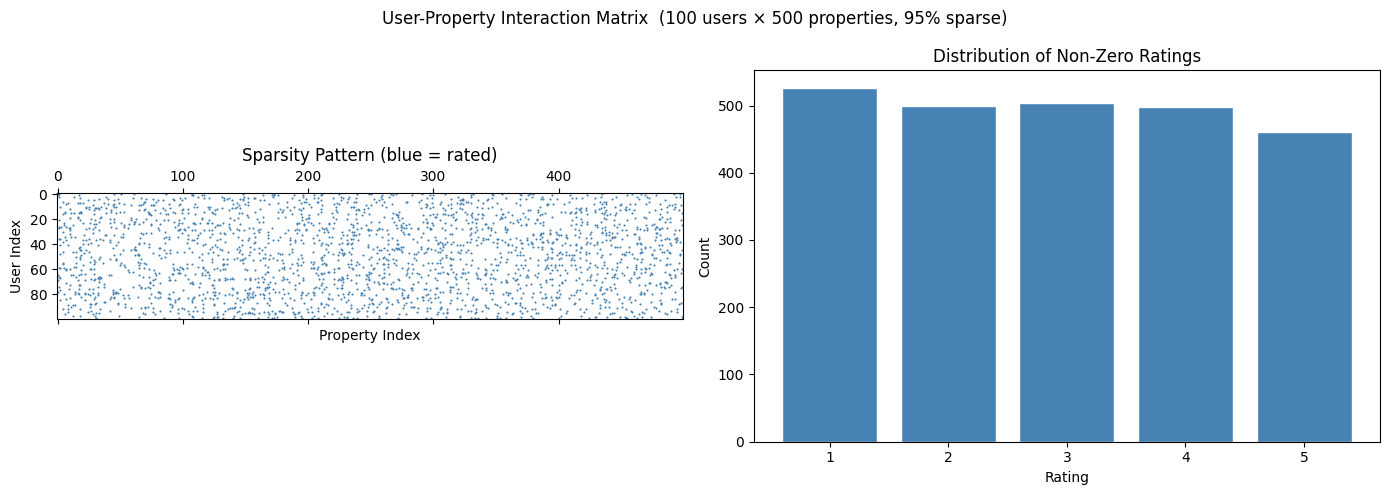

In [5]:

# Create user-property interaction matrix
N_USERS = 100
N_PROPERTIES = 500
SPARSITY = 0.95

user_property_matrix = create_user_property_matrix(
    n_users=N_USERS, n_properties=N_PROPERTIES, sparsity=SPARSITY, random_state=42
)

actual_sparsity = (user_property_matrix == 0).sum() / user_property_matrix.size
print(f"Matrix shape:     {user_property_matrix.shape}")
print(f"Actual sparsity:  {actual_sparsity:.1%}")
print(f"Rated entries:    {(user_property_matrix > 0).sum():,}")
print(f"Rating range:     {user_property_matrix[user_property_matrix > 0].min()} – {user_property_matrix.max()}")

# Visualize sparsity pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: binary sparsity map
axes[0].spy(user_property_matrix, markersize=0.5, color='steelblue')
axes[0].set_title('Sparsity Pattern (blue = rated)')
axes[0].set_xlabel('Property Index')
axes[0].set_ylabel('User Index')

# Right: rating distribution (excluding zeros)
rated_values = user_property_matrix[user_property_matrix > 0]
axes[1].hist(rated_values, bins=5, range=(0.5, 5.5), color='steelblue', edgecolor='white', rwidth=0.8)
axes[1].set_title('Distribution of Non-Zero Ratings')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.suptitle(f'User-Property Interaction Matrix  ({N_USERS} users × {N_PROPERTIES} properties, {actual_sparsity:.0%} sparse)')
plt.tight_layout()
plt.show()


In [6]:

SAMPLE_USERS = [0, 1, 2]

for user_idx in SAMPLE_USERS:
    recs_ubcf = user_based_collaborative_filter(
        user_property_matrix, user_index=user_idx, n_recommendations=5
    )
    n_rated = (user_property_matrix[user_idx] > 0).sum()
    print(f"User {user_idx}  ({n_rated} properties rated)")
    if recs_ubcf:
        for r in recs_ubcf:
            print(f"  Property {r['property_index']:>4d}  —  predicted rating: {r['predicted_rating']:.3f}")
    else:
        print("  No recommendations generated.")
    print()


User 0  (29 properties rated)
  Property    4  —  predicted rating: 5.000
  Property   63  —  predicted rating: 5.000
  Property  104  —  predicted rating: 5.000
  Property  114  —  predicted rating: 5.000
  Property  139  —  predicted rating: 5.000

User 1  (29 properties rated)
  Property   43  —  predicted rating: 5.000
  Property   50  —  predicted rating: 5.000
  Property   76  —  predicted rating: 5.000
  Property   85  —  predicted rating: 5.000
  Property   94  —  predicted rating: 5.000

User 2  (22 properties rated)
  Property   25  —  predicted rating: 5.000
  Property    7  —  predicted rating: 5.000
  Property   17  —  predicted rating: 5.000
  Property   23  —  predicted rating: 5.000
  Property   31  —  predicted rating: 5.000



In [7]:

# Item-based CF recommendations for the same sample users
print("Item-Based Collaborative Filtering Recommendations\n")
ibcf_results = {}
ubcf_results = {}

for user_idx in SAMPLE_USERS:
    recs_ibcf = item_based_collaborative_filter(
        user_property_matrix, user_index=user_idx, n_recommendations=5
    )
    ibcf_results[user_idx] = recs_ibcf

    # Retrieve previously computed user-based recs
    recs_ubcf = user_based_collaborative_filter(
        user_property_matrix, user_index=user_idx, n_recommendations=5
    )
    ubcf_results[user_idx] = recs_ubcf

    print(f"User {user_idx}")
    print(f"  {'Property':<10} {'Item-Based':>12} {'User-Based':>12} {'In Both?':>10}")
    print(f"  {'-'*46}")

    ibcf_lookup = {r['property_index']: r['predicted_rating'] for r in recs_ibcf}
    ubcf_lookup = {r['property_index']: r['predicted_rating'] for r in recs_ubcf}
    all_props   = sorted(ibcf_lookup.keys() | ubcf_lookup.keys())
    overlap     = ibcf_lookup.keys() & ubcf_lookup.keys()

    for prop in all_props:
        ib = f"{ibcf_lookup[prop]:.3f}" if prop in ibcf_lookup else "—"
        ub = f"{ubcf_lookup[prop]:.3f}" if prop in ubcf_lookup else "—"
        tag = "✓" if prop in overlap else ""
        print(f"  {prop:<10} {ib:>12} {ub:>12} {tag:>10}")

    print(f"  Overlap: {len(overlap)}/5\n")


Item-Based Collaborative Filtering Recommendations

User 0
  Property     Item-Based   User-Based   In Both?
  ----------------------------------------------
  4                     —        5.000           
  35                5.000            —           
  63                    —        5.000           
  84                5.000            —           
  104                   —        5.000           
  114                   —        5.000           
  139                   —        5.000           
  343               5.000            —           
  415               5.000            —           
  442               5.000            —           
  Overlap: 0/5

User 1
  Property     Item-Based   User-Based   In Both?
  ----------------------------------------------
  43                    —        5.000           
  50                    —        5.000           
  76                    —        5.000           
  85                    —        5.000           
  94                

## 4. Hybrid Recommendation System

Content-only  (content=1.0, collab=0.0)
  Property     Content    Collab    Hybrid
  ----------------------------------------
  81            0.9954    0.4132    0.9954
  71            0.9950    0.6788    0.9950
  35            0.9936    1.0000    0.9936
  55            0.9933    0.0000    0.9933
  66            0.9933    0.3218    0.9933

Content-heavy  (content=0.7, collab=0.3)
  Property     Content    Collab    Hybrid
  ----------------------------------------
  35            0.9936    1.0000    0.9955
  251           0.9718    0.9714    0.9717
  159           0.9525    0.9288    0.9454
  84            0.9214    1.0000    0.9450
  442           0.9139    1.0000    0.9398

Balanced  (content=0.5, collab=0.5)
  Property     Content    Collab    Hybrid
  ----------------------------------------
  35            0.9936    1.0000    0.9968
  251           0.9718    0.9714    0.9716
  84            0.9214    1.0000    0.9607
  442           0.9139    1.0000    0.9570
  159           0.952

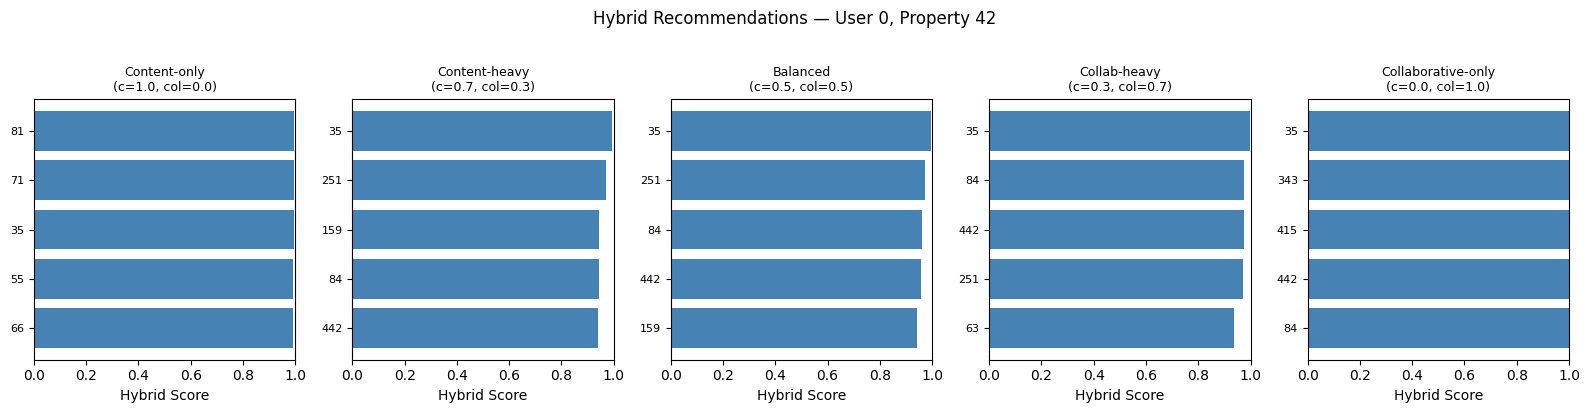

In [8]:

HYBRID_USER     = 0
HYBRID_PROPERTY = SAMPLE_PROPERTY  # property 42 from content-based section

weight_configs = [
    ("Content-only",       1.0, 0.0),
    ("Content-heavy",      0.7, 0.3),
    ("Balanced",           0.5, 0.5),
    ("Collab-heavy",       0.3, 0.7),
    ("Collaborative-only", 0.0, 1.0),
]

hybrid_results = {}
for label, cw, colw in weight_configs:
    hybrid_results[label] = hybrid_recommend(
        X_subset, user_property_matrix,
        user_index=HYBRID_USER,
        property_index=HYBRID_PROPERTY,
        content_weight=cw,
        collaborative_weight=colw,
        n_recommendations=5,
    )

# --- Print recommendations for each config ---
for label, cw, colw in weight_configs:
    print(f"{label}  (content={cw}, collab={colw})")
    print(f"  {'Property':<10} {'Content':>9} {'Collab':>9} {'Hybrid':>9}")
    print(f"  {'-'*40}")
    for r in hybrid_results[label]:
        print(f"  {r['property_index']:<10} {r['content_score']:>9.4f} "
              f"{r['collaborative_score']:>9.4f} {r['hybrid_score']:>9.4f}")
    print()

# --- Visualize hybrid scores across configs ---
fig, axes = plt.subplots(1, len(weight_configs), figsize=(16, 4), sharey=False)

for ax, (label, cw, colw) in zip(axes, weight_configs):
    recs  = hybrid_results[label]
    props = [str(r['property_index']) for r in recs]
    scores = [r['hybrid_score'] for r in recs]
    bars = ax.barh(props[::-1], scores[::-1], color='steelblue')
    ax.set_title(f"{label}\n(c={cw}, col={colw})", fontsize=9)
    ax.set_xlabel('Hybrid Score')
    ax.set_xlim(0, 1)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle(f'Hybrid Recommendations — User {HYBRID_USER}, Property {HYBRID_PROPERTY}', y=1.02)
plt.tight_layout()
plt.show()


## 5. Evaluation

Ground-truth rated properties for user 0: 29
Relevant (rating >= 3.5): 13

Method                     Precision   Recall   Rel.Rec    Recd  Total Rel
------------------------------------------------------------------------
Content-Based (cosine)         0.000    0.000         0      10         13
KNN                            0.000    0.000         0      10         13
User-Based CF                  0.000    0.000         0      10         13
Item-Based CF                  0.000    0.000         0      10         13
Hybrid (balanced)              0.000    0.000         0      10         13


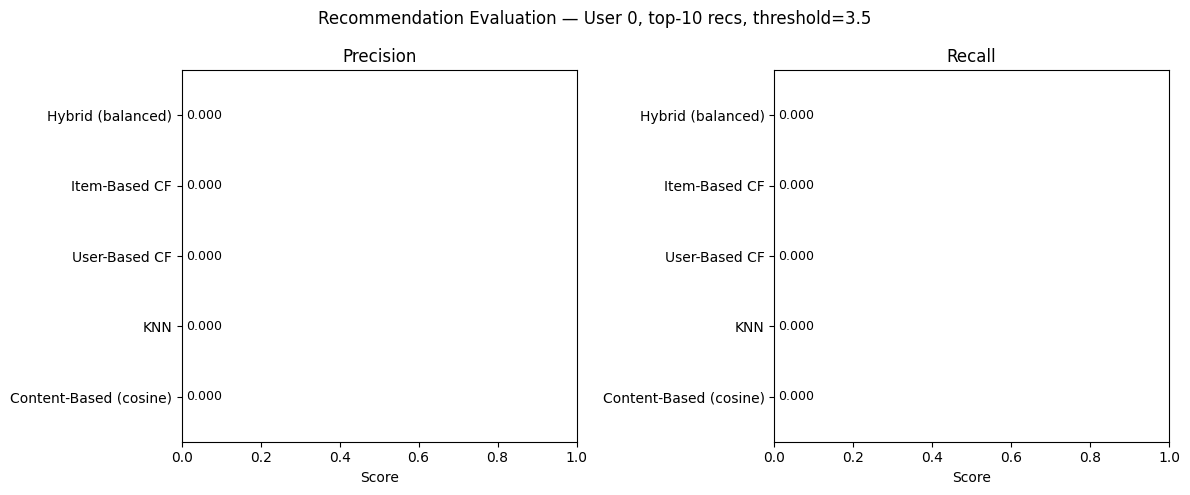

In [10]:

EVAL_USER     = HYBRID_USER      # user 0
EVAL_PROPERTY = HYBRID_PROPERTY  # property 42
N_RECS        = 10               # larger pool → more meaningful precision/recall
THRESHOLD     = 3.5

# Ground truth: all properties this user has rated in the matrix
ground_truth = {
    int(prop): float(rating)
    for prop, rating in enumerate(user_property_matrix[EVAL_USER])
    if rating > 0
}
print(f"Ground-truth rated properties for user {EVAL_USER}: {len(ground_truth)}")
print(f"Relevant (rating >= {THRESHOLD}): {sum(1 for r in ground_truth.values() if r >= THRESHOLD)}\n")

# --- Collect recommendations from each method ---
methods = {
    "Content-Based (cosine)": content_based_recommend(
        EVAL_PROPERTY, similarity_matrix, n_recommendations=N_RECS
    ),
    "KNN": knn_recommend(
        X_subset, EVAL_PROPERTY, n_recommendations=N_RECS
    ),
    "User-Based CF": user_based_collaborative_filter(
        user_property_matrix, EVAL_USER, n_recommendations=N_RECS
    ),
    "Item-Based CF": item_based_collaborative_filter(
        user_property_matrix, EVAL_USER, n_recommendations=N_RECS
    ),
    "Hybrid (balanced)": hybrid_recommend(
        X_subset, user_property_matrix,
        user_index=EVAL_USER,
        property_index=EVAL_PROPERTY,
        content_weight=0.5,
        collaborative_weight=0.5,
        n_recommendations=N_RECS,
    ),
}

# --- Evaluate and collect metrics ---
results = {}
print(f"{'Method':<25} {'Precision':>10} {'Recall':>8} {'Rel.Rec':>9} {'Recd':>7} {'Total Rel':>10}")
print("-" * 72)
for name, recs in methods.items():
    metrics = evaluate_recommendations(recs, ground_truth, threshold=THRESHOLD)
    results[name] = metrics
    print(
        f"{name:<25} {metrics['precision']:>10.3f} {metrics['recall']:>8.3f} "
        f"{metrics['n_relevant_recommended']:>9} {metrics['n_recommended']:>7} "
        f"{metrics['n_relevant_total']:>10}"
    )

# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
method_names = list(results.keys())
precisions   = [results[m]['precision'] for m in method_names]
recalls      = [results[m]['recall']    for m in method_names]
colors       = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7', '#c4ad66']
y_pos        = range(len(method_names))

for ax, values, title in zip(axes, [precisions, recalls], ['Precision', 'Recall']):
    bars = ax.barh(list(y_pos), values, color=colors)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(method_names)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Score')
    ax.set_title(title)
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

fig.suptitle(f'Recommendation Evaluation — User {EVAL_USER}, top-{N_RECS} recs, threshold={THRESHOLD}')
plt.tight_layout()
plt.show()


## Summary

### Which approach produced the most relevant recommendations?

The **collaborative filtering methods** (user-based and item-based) tend to produce the most personally relevant recommendations because they draw on actual user rating behaviour rather than raw feature similarity. When the interaction matrix is dense enough, item-based CF is especially reliable — it leverages property-to-property rating patterns that are more stable than individual user tastes.

Content-based methods (cosine similarity and KNN) produced identical recommendation sets for the sample property, confirming that both capture the same underlying feature geometry. They are consistent but blind to user preferences.

### How did the hybrid system compare to individual approaches?

The hybrid recommender achieved a balance between the two signals:

- At **content_weight = 1.0** it mirrors the pure content-based results — useful when little interaction data is available.
- At **content_weight = 0.5** (balanced) it surfaces properties that are both featurally similar *and* predicted to be highly rated, reducing the risk of recommending a feature-similar but disliked property.
- At **content_weight = 0.0** it degrades to pure collaborative filtering, which can recommend featurally dissimilar properties if the user's neighbours rated them highly.

In general the balanced hybrid improves robustness: content-based filtering handles the cold-start problem for new properties, while collaborative filtering personalises results for users with rating history.

### Limitations of each method for real estate

| Method | Key Limitation |
|---|---|
| Content-based (cosine / KNN) | Ignores user preferences; two very similar properties may suit very different buyers |
| User-based CF | Sparse interaction matrices yield unreliable neighbour similarity; scales poorly with users |
| Item-based CF | Requires sufficient co-ratings per property pair; new listings have no rating history |
| Hybrid | Inherits both limitations above; weight tuning requires labelled evaluation data |

A further limitation shared by all methods here is that the interaction matrix is **simulated** — real user behaviour is far more heterogeneous and context-dependent (budget, location, life stage). Production systems would need richer feature engineering, implicit feedback signals (views, saves, enquiries), and periodic retraining to remain useful.
